In [270]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [271]:
df = pd.read_csv(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\ML_data\taxi_trip_pricing.csv")

In [272]:
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [273]:
df.shape

(1000, 11)

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [275]:
df.dtypes

Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count          float64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

In [276]:
# Missing Values not convert to int so convert it to int64
df['Passenger_Count'] = df['Passenger_Count'].astype('Int64')


In [277]:
df.dtypes

Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count            Int64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

In [278]:
continous = ['Trip_Distance_km','Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']
discrete_count = ['Passenger_Count']

discrete_categorical = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

In [279]:
df[continous].describe()

,Trip_Distance_km,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,5.000000,2.000000,0.500000,119.840000,332.043689


In [280]:
df[continous].skew()

Trip_Distance_km         2.236010
Base_Fare               -0.005149
Per_Km_Rate              0.079206
Per_Minute_Rate          0.058695
Trip_Duration_Minutes    0.017749
Trip_Price               3.732561
dtype: float64

In [281]:
 df['Trip_Distance_km'] = np.log( df['Trip_Distance_km'])

In [282]:
df[continous].skew()

Trip_Distance_km        -0.912487
Base_Fare               -0.005149
Per_Km_Rate              0.079206
Per_Minute_Rate          0.058695
Trip_Duration_Minutes    0.017749
Trip_Price               3.732561
dtype: float64

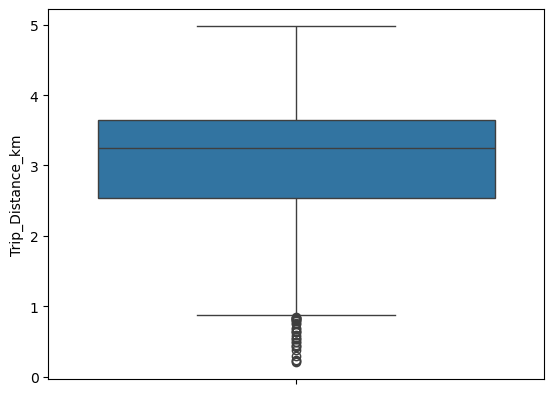

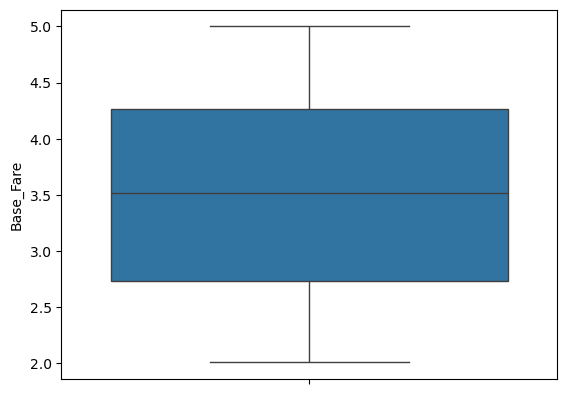

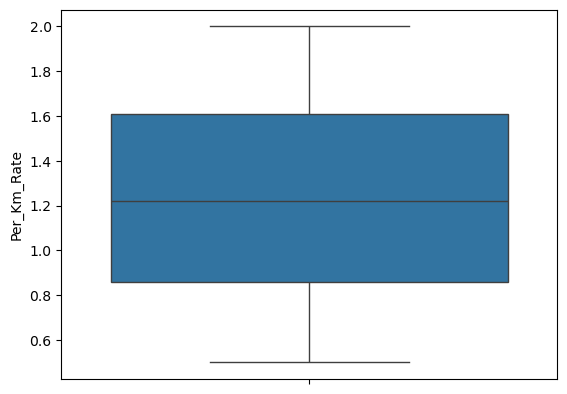

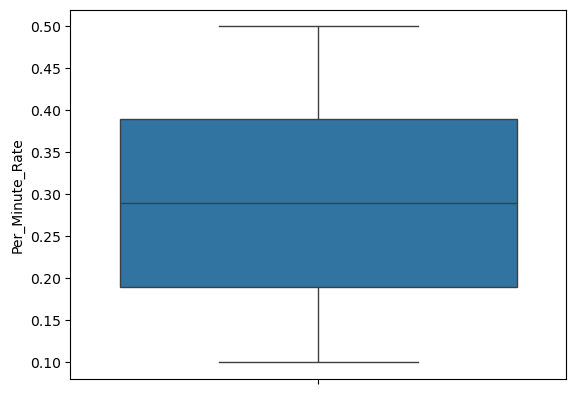

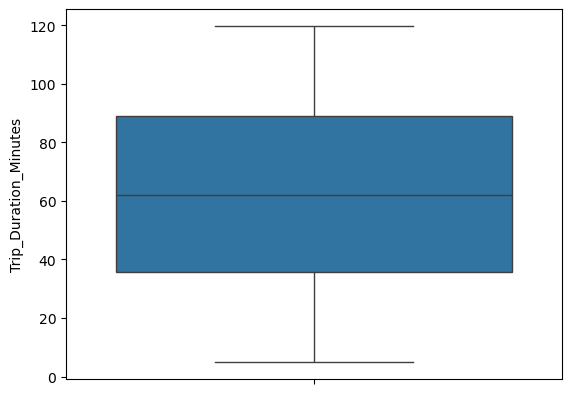

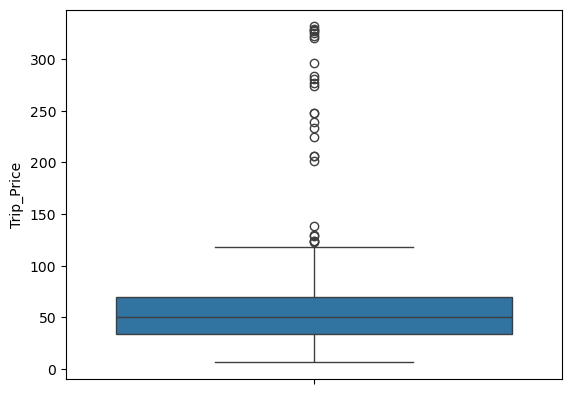

In [283]:
for i in continous:
    sns.boxplot(df[i])
    plt.show()

In [284]:
# check whether any wrong values entered 

df[(df['Trip_Distance_km'] > df['Trip_Distance_km'].max()) | (df['Trip_Distance_km'] < df['Trip_Distance_km'].min())]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price


In [285]:
df[(df['Trip_Price'] > df['Trip_Price'].max()) | (df['Trip_Price'] < df['Trip_Price'].min())]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price


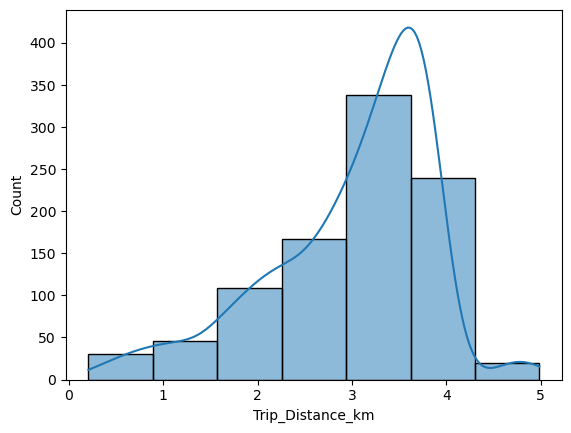

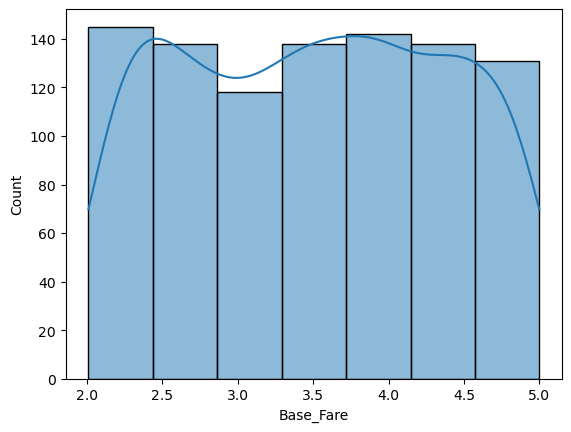

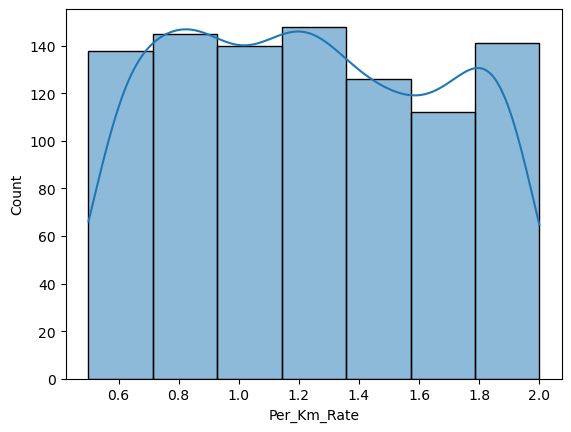

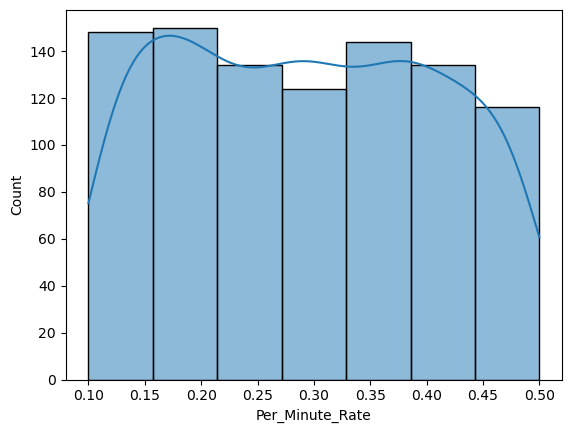

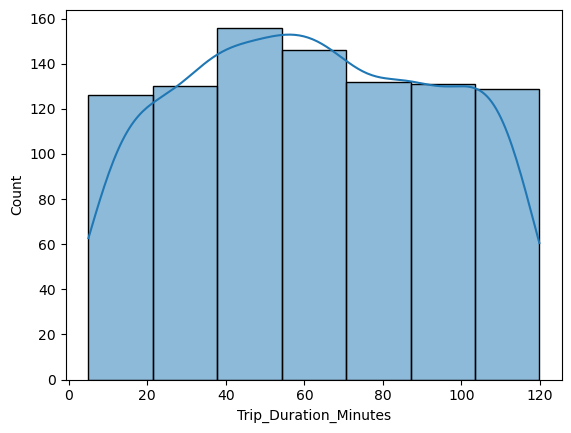

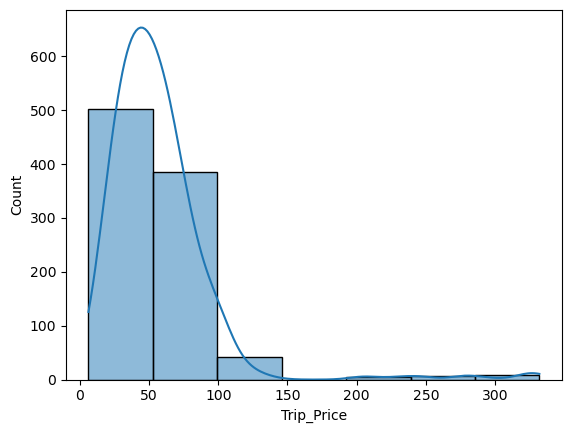

In [286]:
for i in continous:
    sns.histplot(df[i], bins= 7, kde=True)
    plt.show()

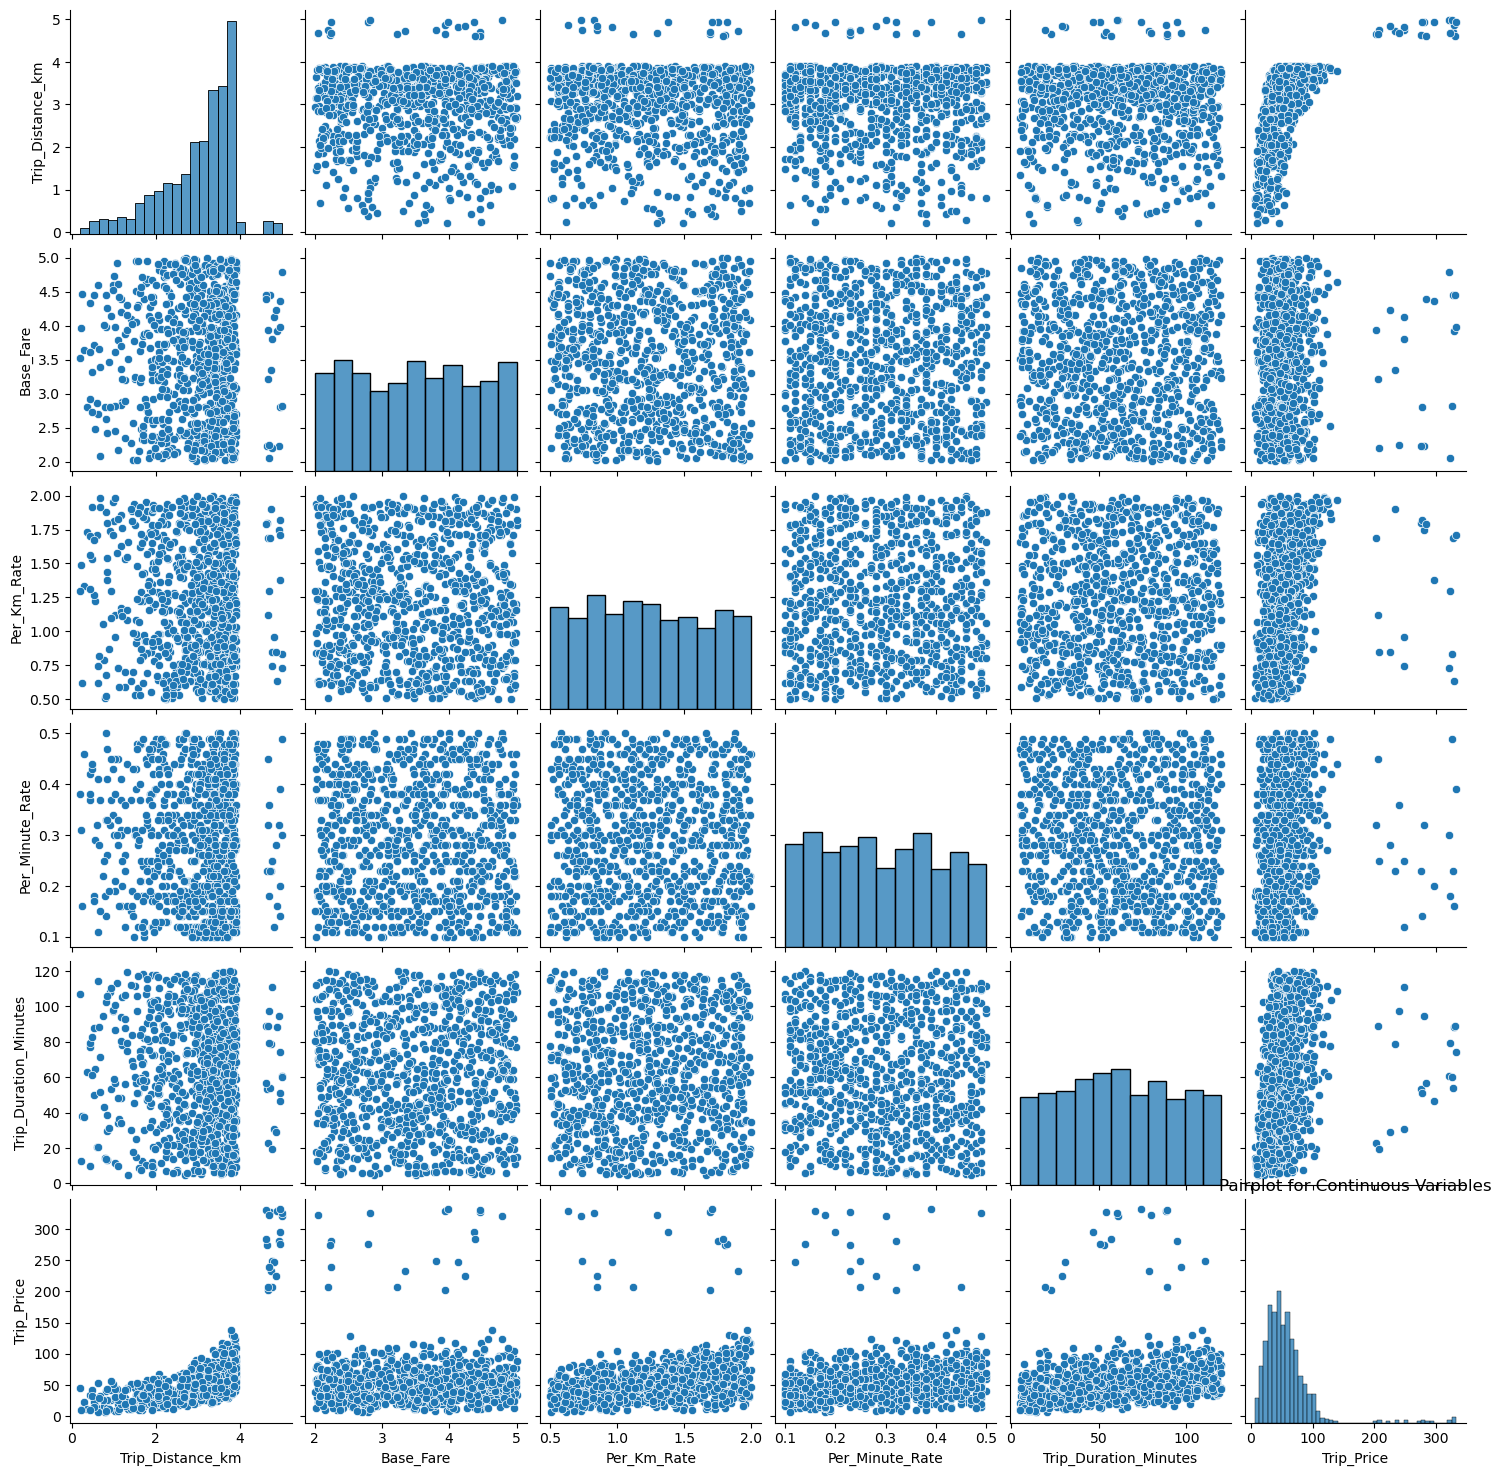

In [287]:
# Apply pairplot
sns.pairplot(df[continous])
plt.title("Pairplot for Continuous Variables")
plt.show()

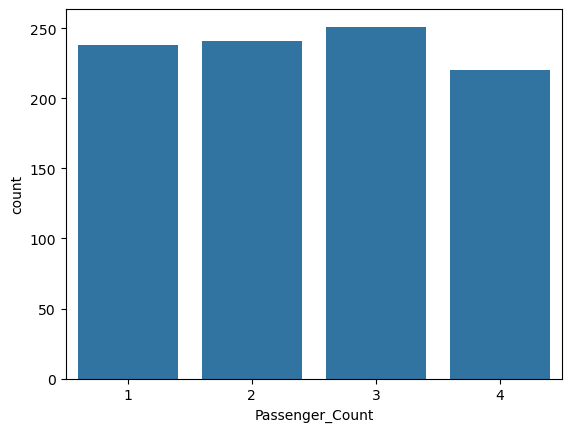

In [288]:
sns.countplot(x = df['Passenger_Count'])
plt.show()

In [289]:
for i in discrete_categorical:
    print(i , " : ", df[i].value_counts())
    print("==============================")

Time_of_Day  :  Time_of_Day
Afternoon    371
Morning      283
Evening      203
Night         93
Name: count, dtype: int64
Day_of_Week  :  Day_of_Week
Weekday    655
Weekend    295
Name: count, dtype: int64
Traffic_Conditions  :  Traffic_Conditions
Low       397
Medium    371
High      182
Name: count, dtype: int64
Weather  :  Weather
Clear    667
Rain     227
Snow      56
Name: count, dtype: int64


In [290]:
df[df.isnull().any(axis = 1)]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
1,3.862623,Afternoon,Weekday,1,High,Clear,NaN,0.62,0.43,40.57,NaN
3,3.412137,Evening,Weekday,4,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3,High,Clear,2.93,0.63,0.32,22.64,15.6180
6,1.348073,Afternoon,Weekday,4,High,Rain,3.51,1.66,NaN,5.05,11.2645
7,3.771381,Evening,Weekend,3,NaN,Clear,2.97,1.87,0.23,NaN,101.1216
...,...,...,...,...,...,...,...,...,...,...,...
991,3.556490,Morning,Weekend,4,Medium,Rain,2.90,1.10,0.15,9.99,NaN
993,NaN,Morning,Weekday,3,Medium,Clear,2.65,1.35,NaN,25.61,55.3348
996,3.827554,Night,Weekday,4,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,2.041220,Morning,Weekday,3,Low,Rain,2.08,1.78,NaN,54.18,33.1236


# Handle missing values

# output columns having missing values remove that records

In [291]:
# Remove rows where 'Trip_Price' has missing values
df = df.dropna(subset=['Trip_Price'])

In [292]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              49
Day_of_Week              46
Passenger_Count          48
Traffic_Conditions       50
Weather                  46
Base_Fare                44
Per_Km_Rate              44
Per_Minute_Rate          49
Trip_Duration_Minutes    46
Trip_Price                0
dtype: int64

In [293]:
df['Trip_Distance_km'].skew()

-0.8994070923036985

In [294]:
import pandas as pd

# Assuming your dataset is in a DataFrame called df

# Handle missing values for numerical columns by filling with median or mean
numerical_columns = ['Trip_Distance_km', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)  # You can replace median() with mean() if you prefer

# Handle missing values for categorical columns by filling with mode
categorical_columns = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)  # Filling with the most frequent value (mode)

# If you want to create a new category for missing data
# df['Traffic_Conditions'].fillna('Unknown', inplace=True)

# After handling missing values, check if they are all imputed
print(df.isnull().sum())  # Should return 0 for all columns if there are no missing values


Trip_Distance_km          0
Time_of_Day               0
Day_of_Week               0
Passenger_Count          48
Traffic_Conditions        0
Weather                   0
Base_Fare                 0
Per_Km_Rate               0
Per_Minute_Rate           0
Trip_Duration_Minutes     0
Trip_Price                0
dtype: int64


C:\Users\SHRI\AppData\Local\Temp\ipykernel_13672\1024166615.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].median(), inplace=True)  # You can replace median() with mean() if you prefer
C:\Users\SHRI\AppData\Local\Temp\ipykernel_13672\1024166615.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].mode()[0], inplace=True)  # Filling with the most frequent value (mode)


In [295]:
df['Passenger_Count'] = df['Passenger_Count'].fillna(round(df['Passenger_Count'].mean())).astype(int)

C:\Users\SHRI\AppData\Local\Temp\ipykernel_13672\1175520621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Passenger_Count'] = df['Passenger_Count'].fillna(round(df['Passenger_Count'].mean())).astype(int)


In [296]:
df.isnull().sum()



Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [297]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,2.962692,Morning,Weekday,3,Low,Clear,3.56,0.80,0.32,53.82,36.2624
2,3.607398,Evening,Weekend,1,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,3.412137,Evening,Weekday,4,Low,Clear,3.48,0.51,0.15,116.81,36.4698
4,3.253084,Evening,Weekday,3,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,2.156403,Afternoon,Weekend,2,Medium,Clear,2.55,1.71,0.48,89.33,60.2028


In [298]:
df[continous].corr()

,Trip_Distance_km,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,0.032003,-0.040994,-0.038466,-0.032139,0.590662
Base_Fare,0.032003,1.000000,0.001006,-0.017302,0.009452,0.035161
Per_Km_Rate,-0.040994,0.001006,1.000000,0.024912,0.028195,0.263500
Per_Minute_Rate,-0.038466,-0.017302,0.024912,1.000000,-0.022522,0.133910
Trip_Duration_Minutes,-0.032139,0.009452,0.028195,-0.022522,1.000000,0.219380
Trip_Price,0.590662,0.035161,0.263500,0.133910,0.219380,1.000000


In [299]:
df = df.drop(columns = ['Base_Fare', 'Per_Minute_Rate'])

# One-Hot Encoding 

In [300]:
df = pd.get_dummies(df, columns=['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], drop_first=True)

In [301]:
df.head()

,Trip_Distance_km,Passenger_Count,Per_Km_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,2.962692,3,0.80,53.82,36.2624,False,True,False,False,True,False,False,False
2,3.607398,1,1.21,37.27,52.9032,True,False,False,True,False,False,False,False
3,3.412137,4,0.51,116.81,36.4698,True,False,False,False,True,False,False,False
4,3.253084,3,0.63,22.64,15.6180,True,False,False,False,False,False,False,False
5,2.156403,2,1.71,89.33,60.2028,False,False,False,True,False,True,False,False


# checking colinearity problem

In [302]:
import pandas as pd
import statsmodels.formula.api as smf 

# Assuming df is your dataframe with relevant columns

# Calculate R-squared values
rsq_Trip_Distance_km = smf.ols("Trip_Distance_km ~ Per_Km_Rate + Trip_Duration_Minutes", data=df).fit().rsquared
vif_Trip_Distance_km = 1 / (1 - rsq_Trip_Distance_km)

rsq_Per_Km_Rate = smf.ols("Per_Km_Rate ~ Trip_Distance_km + Trip_Duration_Minutes", data=df).fit().rsquared
vif_Per_Km_Rate = 1 / (1 - rsq_Per_Km_Rate)

rsq_Trip_Duration_Minutes = smf.ols("Trip_Duration_Minutes ~ Per_Km_Rate + Trip_Distance_km", data=df).fit().rsquared
vif_Trip_Duration_Minutes = 1 / (1 - rsq_Trip_Duration_Minutes)

# Store VIF values in a DataFrame
vif_data = {
    'Variables': ['Trip_Distance_km', 'Per_Km_Rate', 'Trip_Duration_Minutes'],
    'VIF': [vif_Trip_Distance_km, vif_Per_Km_Rate, vif_Trip_Duration_Minutes]
}
vif_frame = pd.DataFrame(vif_data)

# Display VIF values
print(vif_frame)


               Variables       VIF
0       Trip_Distance_km  1.002648
1            Per_Km_Rate  1.002409
2  Trip_Duration_Minutes  1.001760


**Observation**
- VIF Values Near 1: All three variables—Trip_Distance_km, Per_Km_Rate, and Trip_Duration_Minutes—have very low VIF values (close to 1). This indicates that there is no significant multicollinearity between these variables. In other words:

- These variables are not highly correlated with each other.
- The presence of one variable does not inflate the variance of the others in the regression model.



**Now data is ready for regression**


# check for best random state number

**X and y**

In [303]:
import pandas as pd
import statsmodels.formula.api as smf 

# Ensure dummy variables are integers (0/1)
df_encoded = df.copy()
dummy_cols = ['Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 
              'Day_of_Week_Weekend', 'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 
              'Weather_Rain', 'Weather_Snow']

df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

# Calculate R-squared values
rsq_Trip_Distance_km = smf.ols("Trip_Distance_km ~ Per_Km_Rate + Trip_Duration_Minutes + Time_of_Day_Morning + Traffic_Conditions_Low", data=df_encoded).fit().rsquared
vif_Trip_Distance_km = 1 / (1 - rsq_Trip_Distance_km)

rsq_Per_Km_Rate = smf.ols("Per_Km_Rate ~ Trip_Distance_km + Trip_Duration_Minutes + Time_of_Day_Morning + Traffic_Conditions_Low", data=df_encoded).fit().rsquared
vif_Per_Km_Rate = 1 / (1 - rsq_Per_Km_Rate)

rsq_Trip_Duration_Minutes = smf.ols("Trip_Duration_Minutes ~ Per_Km_Rate + Trip_Distance_km + Time_of_Day_Morning + Traffic_Conditions_Low", data=df_encoded).fit().rsquared
vif_Trip_Duration_Minutes = 1 / (1 - rsq_Trip_Duration_Minutes)

# Store VIF values in a DataFrame
vif_data = {
    'Variables': ['Trip_Distance_km', 'Per_Km_Rate', 'Trip_Duration_Minutes'],
    'VIF': [vif_Trip_Distance_km, vif_Per_Km_Rate, vif_Trip_Duration_Minutes]
}
vif_frame = pd.DataFrame(vif_data)

# Display VIF values
print(vif_frame)


               Variables       VIF
0       Trip_Distance_km  1.007726
1            Per_Km_Rate  1.005418
2  Trip_Duration_Minutes  1.006197


In [304]:
X = df.drop(columns = ['Trip_Price'])
y = df['Trip_Price']

In [305]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score


Train = []
CV = []

for i in range(0,10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Training R2 Score
    ypred_train = model.predict(X_train)

    Train.append(r2_score(y_train, ypred_train))

    # Cross-validation score
    CV.append(cross_val_score(model, X_train, y_train, cv=5).mean())

        
# Create a DataFrame after the loop
em = pd.DataFrame({'Train': Train, 'CV': CV})

# Filtering based on condition
gm = em[abs(em['Train'] - em['CV']) <= 0.05]

rs = gm[gm['CV'] == gm['CV'].max()].index.tolist()[0]
print("Best random number is:", rs)


Best random number is: 4


In [306]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 4)

In [307]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score


from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

print('coefficients : ', model.coef_)
print('Intercept : ', model.intercept_)
print("=====================================")

# Prediction R2
ypred_train = model.predict(X_train)
ypred_test = model.predict(X_test)

print("Train_R2 : ", r2_score(y_train, ypred_train))
print("CV_Score_R2", cross_val_score(model, X_train, y_train, cv = 5, scoring = 'r2').mean())
print("Test_R2 : ", r2_score(y_test, ypred_test))

coefficients :  [28.51645112 -0.2577759  26.21295649  0.32557818 -3.62634607 -2.07970715
 -1.37950599 -1.24402286 -6.88834941 -7.42685144  0.09145751  0.85298125]
Intercept :  -72.95197099181824
Train_R2 :  0.49383728536606475
CV_Score_R2 0.50906778534141
Test_R2 :  0.46026961945678624


In [308]:
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf

# Define features and target
X = df.drop(columns=['Trip_Price'])  # Independent variables
y = df['Trip_Price']  # Dependent variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=9)

# Combine X_train and y_train into a single DataFrame for statsmodels
df_train = X_train.copy()
df_train['Trip_Price'] = y_train

# Fit the OLS model
formula = "Trip_Price ~ " + " + ".join(X_train.columns)  # Creating formula dynamically
model1 = smf.ols(formula, data=df_train).fit()

# Show model summary
model1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Trip_Price   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     62.93
Date:                Mon, 10 Feb 2025   Prob (F-statistic):          9.97e-105
Time:                        23:33:32   Log-Likelihood:                -3570.0
No. Observations:                 760   AIC:                             7166.
Df Residuals:                     747   BIC:                             7226.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -69.3925      6.067    -11.438      0.000     -81.302     -57.483
Time_of_Day_Evening[T.True]          -4.3406      2.667     -1.627      0.104      -9.576       0.895
Time_of_Day_Morning[T.True]          -2.6356      2.375     -1.110      0.268      -7.299       2.028
Time_of_Day_Night[T.True]            -3.5512      3.456     -1.028      0.304     -10.335       3.233
Day_of_Week_Weekend[T.True]          -0.0215      2.124     -0.010      0.992      -4.191       4.148
Traffic_Conditions_Low[T.True]       -3.7457      2.722     -1.376      0.169      -9.089       1.598
Traffic_Conditions_Medium[T.True]    -5.4867      2.789     -1.967      0.050     -10.963      -0.011
Weather_Rain[T.True]                  0.5435      2.352      0.231      0.817      -4.074       5.161
Weather_Snow[T.True]                  0.4412      4.223      0.104      0.917      -7.849       8.731
Trip_Distance_km                     26.4628      1.151     22.983      0.000      24.202      28.723
Passenger_Count                      -0.9575      0.897     -1.067      0.286      -2.719       0.804
Per_Km_Rate                          29.1011      2.324     12.523      0.000      24.539      33.663
Trip_Duration_Minutes                 0.2859      0.031      9.094      0.000       0.224       0.348
==============================================================================
Omnibus:                      804.481   Durbin-Watson:                   1.939
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            41752.529
Skew:                           5.038   Prob(JB):                         0.00
Kurtosis:                      37.885   Cond. No.                         455.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [309]:
# drop unimportat columns
df.drop(columns = ["Time_of_Day_Evening", 
    "Time_of_Day_Morning", 
    "Time_of_Day_Night", 
    "Day_of_Week_Weekend", 
    "Traffic_Conditions_Low", 
    "Traffic_Conditions_Medium", 
    "Weather_Rain", 
    "Weather_Snow", 
    "Passenger_Count"], inplace = True)

X = df.drop(columns = ['Trip_Price'])
y = df['Trip_Price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 10)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("intercept : ", model.intercept_)
print("coefficient : ", model.coef_)

ypred_train = model.predict(X_train)
print("Train R2 : ", r2_score(y_train, ypred_train))
print("cross_val_score : ", cross_val_score(model, X_train, y_train, cv = 5).mean())

ypred_test = model.predict(X_test)
print("Test R2 : ", r2_score(y_test, ypred_test))

intercept :  -88.6976180655061
coefficient :  [31.09599354 26.41695566  0.31237151]
Train R2 :  0.47736756927120316
cross_val_score :  0.48076815535747225
Test R2 :  0.501811155033727


In [310]:
df.head()

,Trip_Distance_km,Per_Km_Rate,Trip_Duration_Minutes,Trip_Price
0,2.962692,0.80,53.82,36.2624
2,3.607398,1.21,37.27,52.9032
3,3.412137,0.51,116.81,36.4698
4,3.253084,0.63,22.64,15.6180
5,2.156403,1.71,89.33,60.2028


In [311]:
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf

# Define features and target
X = df.drop(columns=['Trip_Price'])  # Independent variables
y = df['Trip_Price']  # Dependent variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=9)

# Combine X_train and y_train into a single DataFrame for statsmodels
df_train = X_train.copy()
df_train['Trip_Price'] = y_train

# Fit the OLS model
formula = "Trip_Price ~ " + " + ".join(X_train.columns)  # Creating formula dynamically
model1 = smf.ols(formula, data=df_train).fit()

# Show model summary
model1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Trip_Price   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     249.3
Date:                Mon, 10 Feb 2025   Prob (F-statistic):          1.88e-112
Time:                        23:35:00   Log-Likelihood:                -3574.1
No. Observations:                 760   AIC:                             7156.
Df Residuals:                     756   BIC:                             7175.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -77.4326      5.065    -15.289      0.000     -87.375     -67.490
Trip_Distance_km         26.6646      1.144     23.308      0.000      24.419      28.910
Per_Km_Rate              28.6453      2.301     12.448      0.000      24.128      33.163
Trip_Duration_Minutes     0.2878      0.031      9.214      0.000       0.227       0.349
==============================================================================
Omnibus:                      819.982   Durbin-Watson:                   1.932
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            44990.746
Skew:                           5.182   Prob(JB):                         0.00
Kurtosis:                      39.240   Cond. No.                         377.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""